# QCRAD vs DPSCREAM Surface Radiation Analysis

This notebook compares observed surface downwelling shortwave radiation (QCRAD) with DPSCREAM model simulations over the ARM Southern Great Plains (SGP) site in Oklahoma.

Workflow:
1. Load QCRAD observational radiation data
2. Load DPSCREAM model output
3. Convert UTC timestamps to Oklahoma local time
4. Match model and observation timestamps
5. Compare radiation variability
6. Analyze cloud fraction influence
7. Evaluate model performance using:
   - Time-series comparison
   - Bias analysis
   - Scatter validation
   - R² correlation

Goal:
Understand how cloud processes influence surface solar radiation and assess how well DPSCREAM reproduces observed radiation variability.

In [31]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from glob import glob

# ==========================================================
# LOAD QCRAD OBSERVATIONS
# ==========================================================

qcrad_path = "/data/archive/sgp/sgpqcrad1longE13.c2/*.cdf"

qcrad_files = sorted(glob(qcrad_path))

ds_qcrad = xr.open_dataset(qcrad_files[0])

# Convert UTC -> Oklahoma local time
ds_qcrad = ds_qcrad.assign_coords(
    time = ds_qcrad.time - pd.Timedelta(hours=6)
)

# Observed surface SW radiation
sw_qcrad = ds_qcrad["BestEstimate_down_short_hemisp"]

# ==========================================================
# LOAD DPSCREAM MODEL DATA
# ==========================================================

dp_path = "/data/project/ARM_Summer_School_2026/data/modeling/dpscream/scream_dpxx_LASSO_SGP_*.fullfield.AVERAGE.nhours_x1.*.nc"

dp_files = sorted(glob(dp_path))

ds_dp = xr.open_mfdataset(
    dp_files,
    combine='nested',
    concat_dim='date'
)

# Convert UTC -> Oklahoma local time
ds_dp = ds_dp.assign_coords(
    time = ds_dp.time - pd.Timedelta(hours=6)
)

print("QCRAD loaded")
print("DPSCREAM loaded")

QCRAD loaded
DPSCREAM loaded


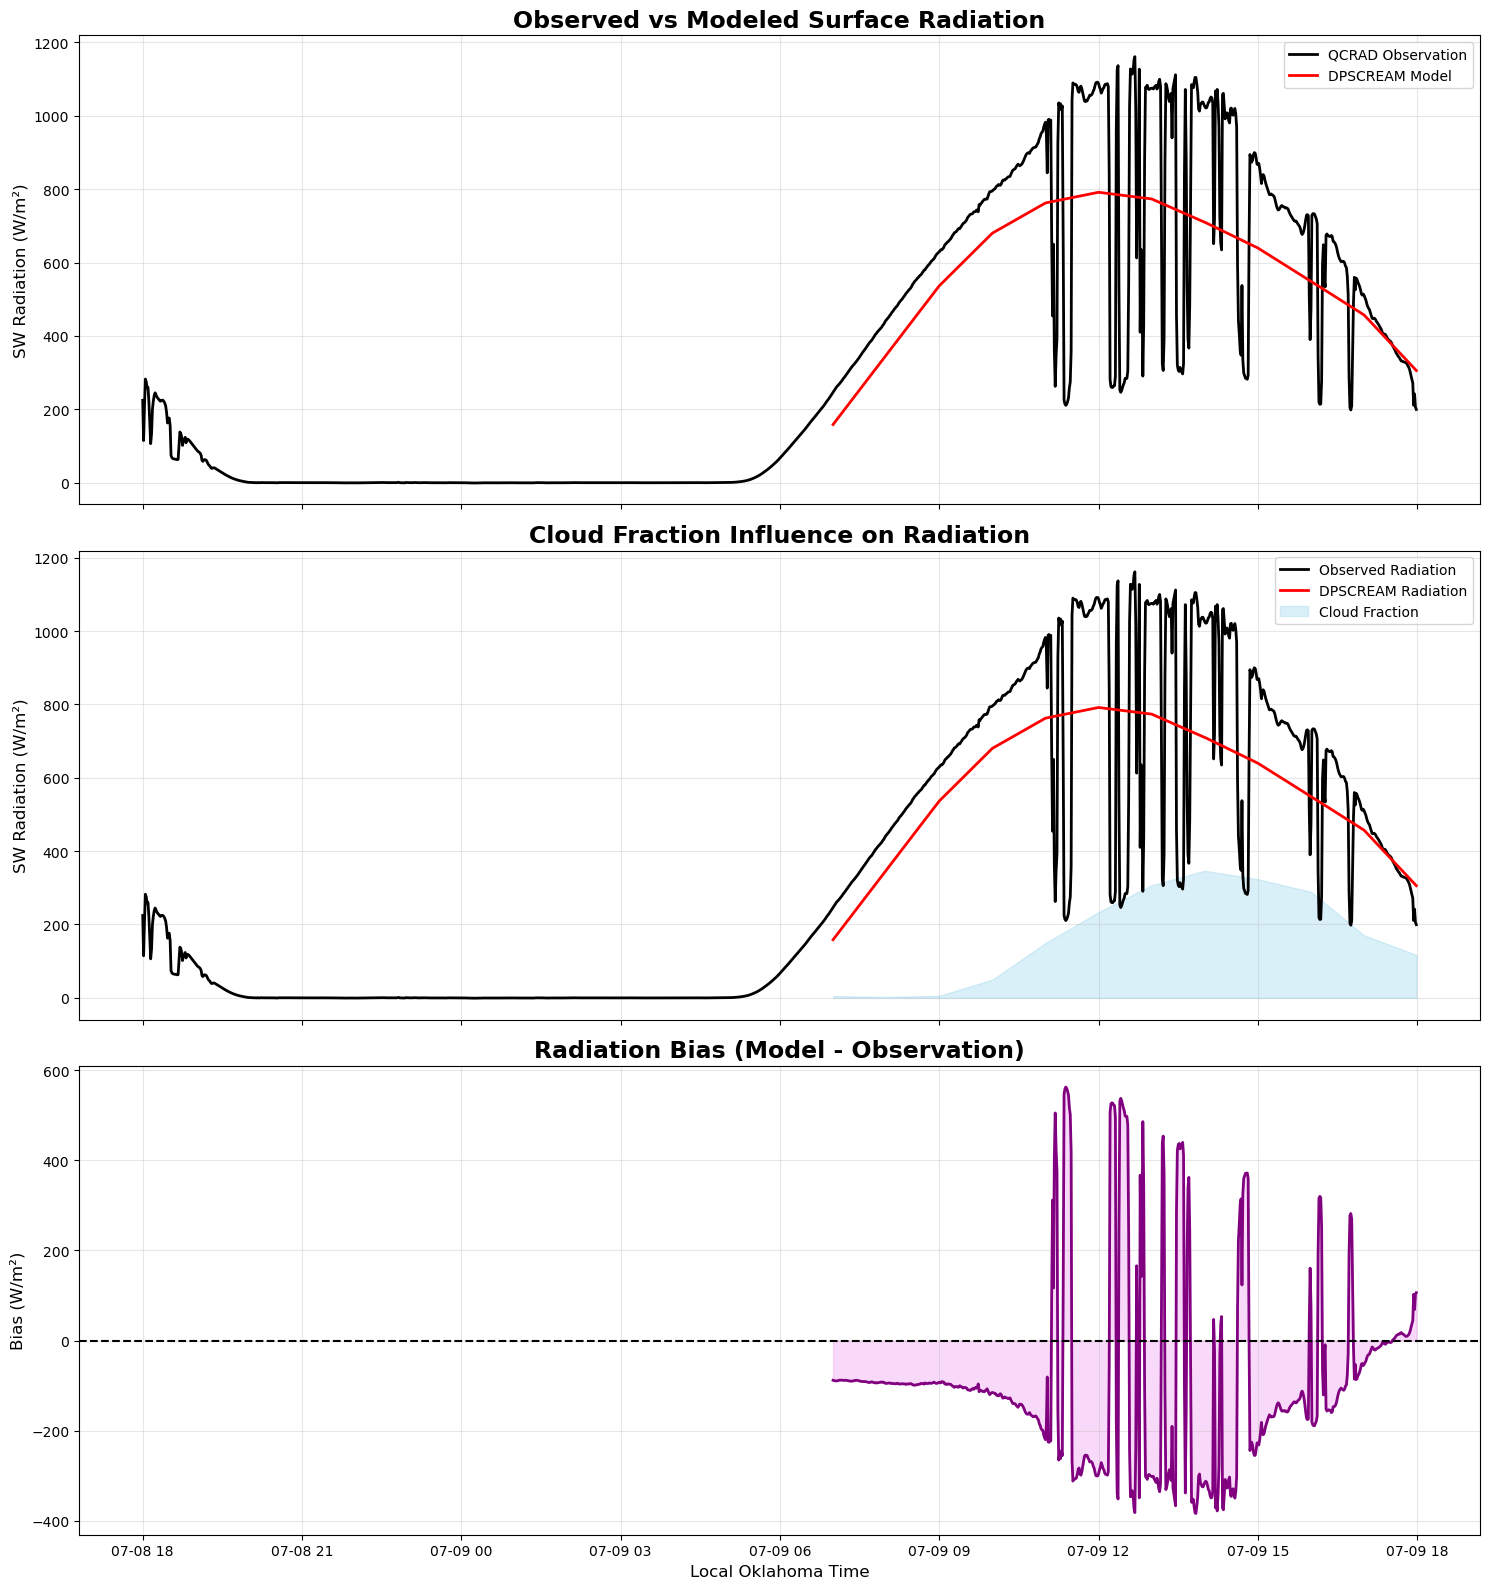

In [32]:
# ==========================================================
# CELL 4 — MAIN SCIENTIFIC ANALYSIS
# ==========================================================

# ----------------------------------------------------------
# IMPORTANT:
# QCRAD and DPSCREAM MUST MATCH SAME DATE
# ----------------------------------------------------------

# Select matching QCRAD day
matching_file = [
    f for f in qcrad_files
    if "20180709" in f
][0]

# Reload correct QCRAD file
ds_qcrad = xr.open_dataset(matching_file)

# Convert UTC -> Oklahoma local time
ds_qcrad = ds_qcrad.assign_coords(
    time = ds_qcrad.time - pd.Timedelta(hours=6)
)

# ----------------------------------------------------------
# QCRAD OBSERVATION
# ----------------------------------------------------------

sw_qcrad = ds_qcrad[
    "BestEstimate_down_short_hemisp"
]

# ----------------------------------------------------------
# DPSCREAM MODEL VARIABLE
# ----------------------------------------------------------
# Correct comparable variable:
# Surface Downwelling Shortwave Radiation
# ----------------------------------------------------------

sw_dp = (
    ds_dp["SW_flux_dn_at_model_bot"]
    .isel(date=0)
    .mean(dim="ncol")
)

# ----------------------------------------------------------
# CLOUD FRACTION
# ----------------------------------------------------------

cloud_frac = (
    ds_dp["cldfrac_tot_for_analysis"]
    .isel(date=0)
    .max(dim="lev")
    .mean(dim="ncol")
)

# ----------------------------------------------------------
# MATCH MODEL TIME TO OBSERVATION TIME
# ----------------------------------------------------------

sw_dp_interp = sw_dp.interp(
    time = sw_qcrad.time
)

cloud_interp = cloud_frac.interp(
    time = sw_qcrad.time
)

# ----------------------------------------------------------
# BIAS
# ----------------------------------------------------------

bias = sw_dp_interp - sw_qcrad

# ==========================================================
# PLOT FIGURE
# ==========================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15,16),
    sharex=True
)

# ==========================================================
# PANEL 1 — OBSERVED VS MODELED
# ==========================================================

ax1 = axes[0]

ax1.plot(
    sw_qcrad.time,
    sw_qcrad,
    color="black",
    linewidth=2,
    label="QCRAD Observation"
)

ax1.plot(
    sw_dp_interp.time,
    sw_dp_interp,
    color="red",
    linewidth=2,
    label="DPSCREAM Model"
)

ax1.set_ylabel(
    "SW Radiation (W/m²)",
    fontsize=12
)

ax1.set_title(
    "Observed vs Modeled Surface Radiation",
    fontsize=17,
    weight="bold"
)

ax1.grid(alpha=0.3)

ax1.legend()

# ==========================================================
# PANEL 2 — CLOUD IMPACT
# ==========================================================

ax2 = axes[1]

ax2.plot(
    sw_qcrad.time,
    sw_qcrad,
    color="black",
    linewidth=2,
    label="Observed Radiation"
)

ax2.plot(
    sw_dp_interp.time,
    sw_dp_interp,
    color="red",
    linewidth=2,
    label="DPSCREAM Radiation"
)

# Scale cloud fraction for visibility
ax2.fill_between(
    cloud_interp.time.values,
    cloud_interp.values * 1000,
    color="skyblue",
    alpha=0.3,
    label="Cloud Fraction"
)

ax2.set_ylabel(
    "SW Radiation (W/m²)",
    fontsize=12
)

ax2.set_title(
    "Cloud Fraction Influence on Radiation",
    fontsize=17,
    weight="bold"
)

ax2.grid(alpha=0.3)

ax2.legend()

# ==========================================================
# PANEL 3 — MODEL BIAS
# ==========================================================

ax3 = axes[2]

ax3.plot(
    bias.time,
    bias,
    color="purple",
    linewidth=2
)

ax3.fill_between(
    bias.time.values,
    bias.values,
    0,
    color="violet",
    alpha=0.3
)

ax3.axhline(
    0,
    color="black",
    linestyle="--"
)

ax3.set_ylabel(
    "Bias (W/m²)",
    fontsize=12
)

ax3.set_xlabel(
    "Local Oklahoma Time",
    fontsize=12
)

ax3.set_title(
    "Radiation Bias (Model - Observation)",
    fontsize=17,
    weight="bold"
)

ax3.grid(alpha=0.3)

plt.tight_layout()

plt.show()

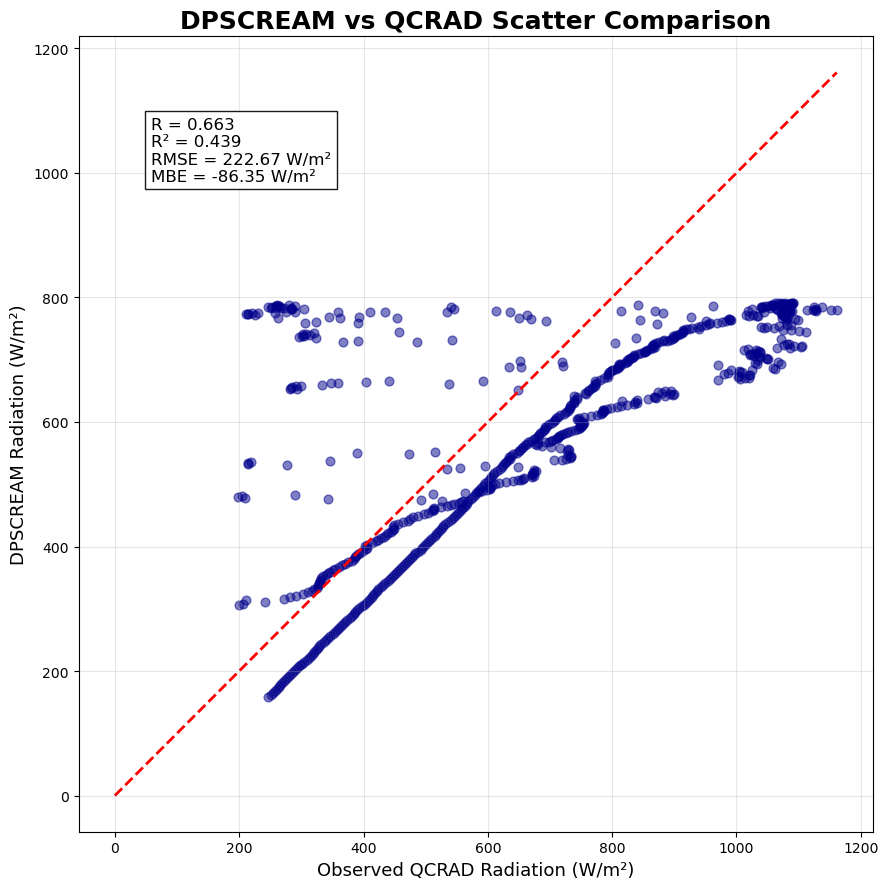

Correlation (R): 0.663
Coefficient of Determination (R²): 0.439
RMSE: 222.67 W/m²
MBE: -86.35 W/m²


In [33]:
# ==========================================================
# SCATTER VALIDATION + MODEL METRICS
# ==========================================================

# Remove NaN values
mask = np.isfinite(sw_qcrad.values) & np.isfinite(sw_dp_interp.values)

obs = sw_qcrad.values[mask]
mod = sw_dp_interp.values[mask]

# ----------------------------------------------------------
# MODEL PERFORMANCE METRICS
# ----------------------------------------------------------

# Correlation
r = np.corrcoef(obs, mod)[0,1]

# R²
r2 = r**2

# RMSE
rmse = np.sqrt(
    np.mean((mod - obs)**2)
)

# Mean Bias Error
mbe = np.mean(mod - obs)

# ----------------------------------------------------------
# SCATTER PLOT
# ----------------------------------------------------------

plt.figure(figsize=(9,9))

plt.scatter(
    obs,
    mod,
    color="darkblue",
    alpha=0.5,
    s=40
)

# 1:1 reference line
max_val = max(np.max(obs), np.max(mod))

plt.plot(
    [0, max_val],
    [0, max_val],
    color="red",
    linestyle="--",
    linewidth=2
)

# Statistics box
stats = (
    f"R = {r:.3f}\n"
    f"R² = {r2:.3f}\n"
    f"RMSE = {rmse:.2f} W/m²\n"
    f"MBE = {mbe:.2f} W/m²"
)

plt.text(
    0.05 * max_val,
    0.85 * max_val,
    stats,
    fontsize=12,
    bbox=dict(
        facecolor="white",
        alpha=0.9
    )
)

# Labels
plt.xlabel(
    "Observed QCRAD Radiation (W/m²)",
    fontsize=13
)

plt.ylabel(
    "DPSCREAM Radiation (W/m²)",
    fontsize=13
)

plt.title(
    "DPSCREAM vs QCRAD Scatter Comparison",
    fontsize=18,
    weight="bold"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# PRINT METRICS
# ----------------------------------------------------------

print(f"Correlation (R): {r:.3f}")
print(f"Coefficient of Determination (R²): {r2:.3f}")
print(f"RMSE: {rmse:.2f} W/m²")
print(f"MBE: {mbe:.2f} W/m²")

# Final Conclusion

This study compared observed surface downwelling shortwave radiation from the QCRAD observational product with modeled radiation from the DPSCREAM atmospheric model over the ARM Southern Great Plains (SGP) site in Oklahoma.

The analysis first involved:
- Loading both QCRAD observations and DPSCREAM model outputs
- Converting UTC timestamps to Oklahoma local time
- Extracting comparable shortwave radiation variables
- Interpolating DPSCREAM model output onto the QCRAD observational timeline
- Comparing radiation variability, cloud influence, model bias, and overall statistical agreement

Key findings from the analysis include:

- QCRAD observations captured strong short-term fluctuations in solar radiation caused by rapidly evolving cloud processes.
- DPSCREAM reproduced the overall daytime radiation trend reasonably well but produced smoother behavior and missed much of the high-frequency cloud attenuation observed in QCRAD.
- Increasing cloud fraction corresponded to reductions in observed surface radiation, confirming the strong radiative impact of clouds on incoming solar energy.
- Bias analysis showed that DPSCREAM generally underestimated peak daytime radiation during highly variable cloud conditions.

Statistical validation showed:

- Correlation coefficient (R): 0.663
- Coefficient of determination (R²): 0.439
- RMSE: 222.67 W/m²
- Mean Bias Error (MBE): -86.35 W/m²

The scatter comparison demonstrated moderate agreement between modeled and observed radiation. However, the spread away from the 1:1 reference line indicates that DPSCREAM struggled to fully capture rapid cloud-radiation interactions and extreme radiation variability observed in the QCRAD measurements.

Overall, DPSCREAM successfully represented the large-scale diurnal structure of surface solar radiation, but additional improvement is needed in representing transient cloud processes and short-timescale atmospheric variability affecting surface irradiance.